In [1]:
from glob import glob
from subspaceadonnx import SubspaceAD, visualize

In [2]:
# Prepare directories with good images and images with defects
NORMAL_IMG_DIR = "datasets/transistor/train/good"
TEST_IMG_DIR = "datasets/transistor/test/bent_lead"

In [3]:
model = SubspaceAD(
    "models/dinov3_vitb_448_3-6_7-10.onnx", # prepared model using export_onnx.py
    providers=["WebGpuExecutionProvider"]
)

### Fit model

In [4]:
# normal_imgs = [cv2.imread(f) for f in glob(f"{NORMAL_IMG_DIR}/*.png")]
model.fit(NORMAL_IMG_DIR)  # pass directory containing images or list[np.ndarray]

Extracting features:   0%|          | 0/213 [00:00<?, ?images/s]

Shared-PPCA mixture candidate: separation=0.108558, cluster_sizes=[80, 112], enabled=True
Fitting branch 1/2 PCA on 150528 patch tokens with feature dim 768.
Shared-PPCA mixture candidate: separation=0.151904, cluster_sizes=[87, 105], enabled=True
Fitting branch 2/2 PCA on 150528 patch tokens with feature dim 768.
Adaptive local-tail fitted: position_variance_ratio=0.444713, spatial_correlation=0.864587, mode=position
INSID3 positional debias enabled: components=2, alpha=1
Shared-PPCA mixture candidate: separation=0.105901, cluster_sizes=[79, 113], enabled=True
Fitting branch 1/2 PCA on 150528 patch tokens with feature dim 768.
Shared-PPCA mixture candidate: separation=0.150786, cluster_sizes=[86, 106], enabled=True
Fitting branch 2/2 PCA on 150528 patch tokens with feature dim 768.
Adaptive local-tail fitted: position_variance_ratio=0.421311, spatial_correlation=0.860532, mode=position
Calibrating anomaly-map scale
Anomaly-map scale calibrated: offset=0.394791, fit_max=2.47882, scale=

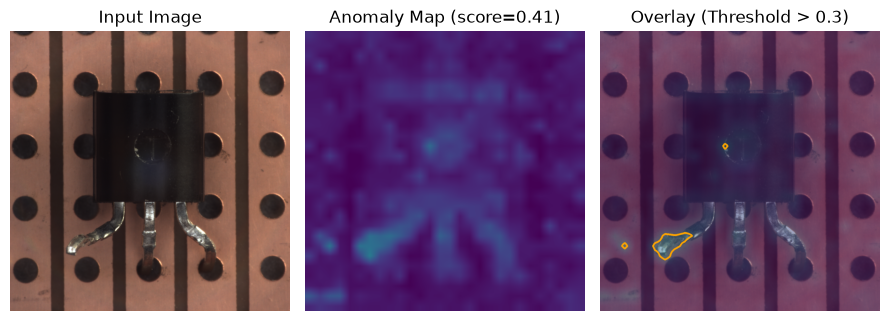

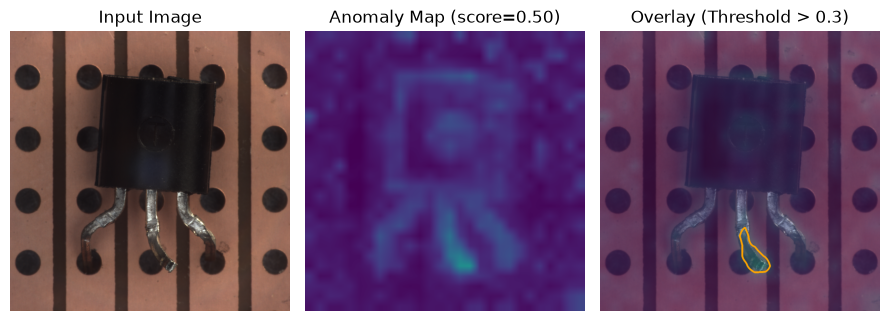

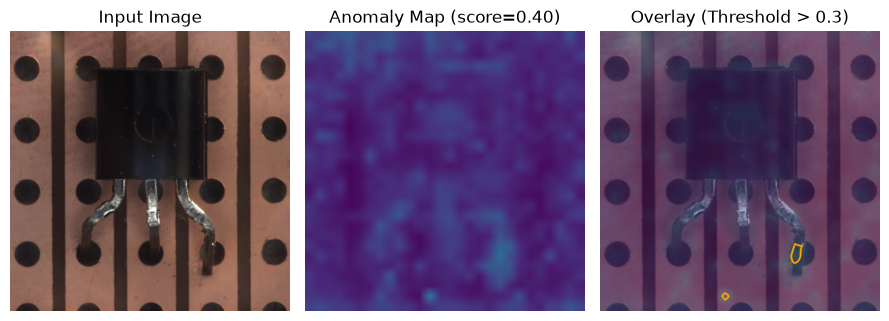

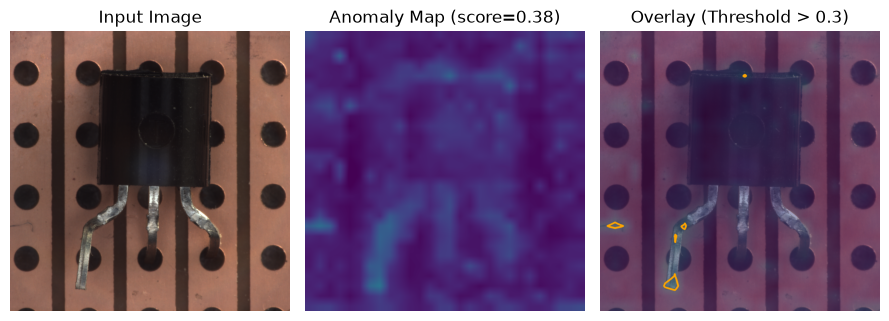

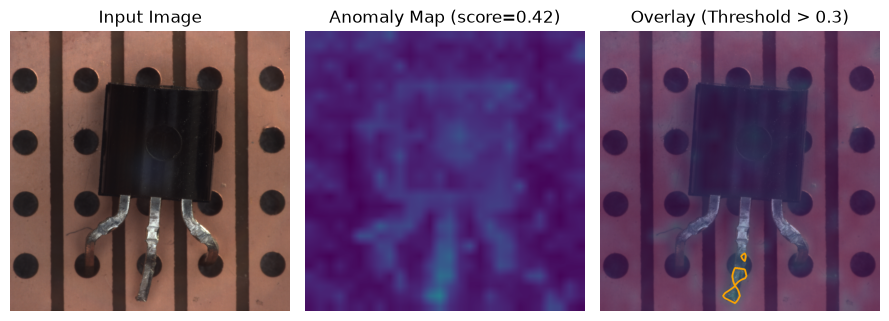

In [5]:
target_img_paths = glob(f"{TEST_IMG_DIR}/*.png")
for target_img_path in target_img_paths[:5]:
    anomaly_map, image_score = model(target_img_path)
    visualize(target_img_path, anomaly_map, image_score, threshold=0.3)

### Save & load fitted model

In [33]:
# save PCA parameters to a file
pca_params = model.save_npz("models/pca_params.npz")
# load PCA parameters from a file
model.load_npz("models/pca_params.npz")

### Run evaluation on MVTec Dataset

In [36]:
from subspaceadonnx import MVTecEvaluator

evaluator = MVTecEvaluator(
    dataset_root="datasets",
    dataset_names=["bottle", "capsule","carpet","grid",
                   "hazelnut", "leather","screw","tile",
                   "toothbrush", "transistor", "wood"],
    onnx_path="models/dinov3_vitsplus_448_3-6_7-10.onnx",
    providers=["WebGpuExecutionProvider"]
)
result = evaluator.evaluate(save_hist=True)
for key, v in result.items():
    print(f"{key}: {v}")

[MVTec 1/11][bottle] Start fitting (209imgs)


Extracting features:   0%|          | 0/209 [00:00<?, ?images/s]

Fitting branch 1/2 PCA on 147392 patch tokens with feature dim 384.
Fitting branch 2/2 PCA on 147392 patch tokens with feature dim 384.
Adaptive local-tail fitted: position_variance_ratio=0.850392, spatial_correlation=0.946736, mode=disabled
Calibrating anomaly-map scale
Anomaly-map scale calibrated: offset=0.0333587, fit_max=3.14545, scale=0.160664, scaled_max=0.5, pixel_threshold=0.302621, image_threshold=0.444685
[MVTec 1/11][bottle] Training completed


[MVTec 1/11][bottle] Inference:   0%|          | 0/83 [00:00<?, ?images/s]

[MVTec 1/11][bottle] Start evaluation
[MVTec 1/11][bottle] Evaluation completed (image AUROC=1.0000, pixel AUROC=0.9908)
[MVTec 2/11][capsule] Start fitting (219imgs)


...

[MVTec 10/11][transistor] Start evaluation
[MVTec 10/11][transistor] Evaluation completed (image AUROC=0.9642, pixel AUROC=0.9271)
[MVTec 11/11][wood] Start fitting (247imgs)


Extracting features:   0%|          | 0/247 [00:00<?, ?images/s]

Fitting branch 1/2 PCA on 174048 patch tokens with feature dim 384.
Fitting branch 2/2 PCA on 174048 patch tokens with feature dim 384.
Adaptive local-tail fitted: position_variance_ratio=0.0661231, spatial_correlation=0.71643, mode=disabled
Calibrating anomaly-map scale
Anomaly-map scale calibrated: offset=0.420406, fit_max=2.83426, scale=0.207138, scaled_max=0.5, pixel_threshold=0.179, image_threshold=0.297128
[MVTec 11/11][wood] Training completed


[MVTec 11/11][wood] Inference:   0%|          | 0/79 [00:00<?, ?images/s]

[MVTec 11/11][wood] Start evaluation
[MVTec 11/11][wood] Evaluation completed (image AUROC=0.9798, pixel AUROC=0.9737)
date: 2026-07-06 00:11:31
description: dinov3_vitsplus_448_3-6_7-10
datasets: bottle;capsule;carpet;grid;hazelnut;leather;screw;tile;toothbrush;transistor;wood
img_auroc: 0.9801011876578943
img_aupr: 0.9901305231961799
seg_auroc: 0.9842253364067317
seg_pro: 0.952954917681804
